# Part (a): Ireland single-country electricity model

This notebook builds a simple PyPSA model for Ireland using hourly electricity demand, solar availability, and onshore wind availability.

The model includes:
- one electricity bus
- one load
- three generation technologies:
  - solar PV
  - onshore wind
  - offshore wind 
  - gas

The goal is to determine the optimal generation capacities and analyse:
- winter dispatch
- summer dispatch
- annual electricity mix
- capacity factors

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
from pathlib import Path

from pyomo.contrib.appsi.solvers.gurobi import gurobipy

explanation: This cell simply imports the three main libraries that will be used throughout the notebook. Pandas is used to read and manipulate the data files, such as the CSV files containing electricity demand, solar availability, and wind availability. Matplotlib is used to create graphs that help visualize the data and the model results, for example load curves or generation dispatch plots. PyPSA is the library used to build and optimize the electricity system model itself; it allows us to define the network structure, add generators and loads, and compute the cost-optimal generation capacities and dispatch. At this stage, no calculations are performed yet, the code is only preparing the tools needed for the rest of the analysis.

1. Model settings

In [2]:
def annualize(capex, r, lifetime):
    crf = (r * (1 + r)*lifetime) / ((1 + r)*lifetime - 1)
    return capex * crf

r = 0.04

In [3]:
YEAR = 2019

FILE_DIR= Path.cwd()

BASE_PATH = FILE_DIR/"data"
DENMARK_PATH = BASE_PATH/"Denmark_En_DH"
LOAD_PATH = BASE_PATH/"Load/time_series_60min_singleindex.csv"

CAPITAL_COST_SOLAR    = float(annualize(450000,   r, lifetime=30))
CAPITAL_COST_WIND_ON  = float(annualize(1220000, r, lifetime=25)) + 23424
CAPITAL_COST_WIND_OFF = float(annualize(2918000, r, lifetime=30)) +50000
CAPITAL_COST_GAS      = float(annualize(1300000,   r, lifetime=25)) +29300

MARGINAL_COST_SOLAR = 0
MARGINAL_COST_WIND_ON = 2
MARGINAL_COST_WIND_OFF = 5
MARGINAL_COST_GAS = 43.18/0.47 + 4.5

explanation for us: This block defines the main settings of the model. First, we have selected the year of data that will be used in the simulation. The next lines define the file paths to access the input datasets: the folder containing the renewable generation data for Ireland and the file containing the electricity demand time series.

The last part defines the cost assumptions for the generation technologies (solar, wind, and gas). These include capital costs, which represent the annualized investment needed to build generation capacity, and marginal costs, which represent the cost of producing electricity.

2. Read input data

In [4]:
#solar, wind, and electricity demand datasets are read from the CSV files
pv = pd.read_csv(
    f"{DENMARK_PATH}/ninja-pv-country-DK-national-merra2.csv",
    skiprows=3
)
# IMPORTANT: skiprows=3 is used to skip the first three rows of the CSV file, which may contain metadata or headers that are not part of the actual data. This ensures that the DataFrame is correctly structured with the appropriate columns and data types.
wind_on = pd.read_csv(
    f"{DENMARK_PATH}/ninja-wind-country-DK-current_onshore-merra2.csv",
    skiprows=3
)
wind_off = pd.read_csv(
    f"{DENMARK_PATH}/ninja-wind-country-DK-current_offshore-merra2.csv",
    skiprows=3
)
load_df = pd.read_csv(LOAD_PATH)

# Parse timestamps as UTC-aware, 
pv["time"] = pd.to_datetime(pv["time"], utc=True)
wind_on["time"] = pd.to_datetime(wind_on["time"], utc=True)
wind_off["time"] = pd.to_datetime(wind_off["time"], utc=True)
load_df["utc_timestamp"] = pd.to_datetime(load_df["utc_timestamp"], utc=True)

# Set index
pv = pv.set_index("time")
wind_on = wind_on.set_index("time")
wind_off = wind_off.set_index("time")
load_df = load_df.set_index("utc_timestamp")

# Convert all indices to timezone-naive
pv.index = pv.index.tz_convert(None)
wind_on.index = wind_on.index.tz_convert(None)
wind_off.index = wind_off.index.tz_convert(None)
load_df.index = load_df.index.tz_convert(None)

# Keep only the year WE want
pv = pv.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]
wind_on = wind_on.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]
wind_off = wind_off.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]
load_df = load_df.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]

#IPORTAT: the timestamp columns are converted into proper datetime objects using pd.to_datetime, initially treating them as UTC timestamps. These timestamps are then set as the index of each dataset so that the data can be handled as time series. After that, the timezone information is removed because PyPSA requires timestamps without timezone information. 
#FOR THIS PART I USED CHAT GPT BECAUSE AT THE BEGGINING I HAD ERROR OR EMPTY INFORMATION SO I COULD NOT UNDERSTAND WHAT WAS GOING ON.

# Build snapshots:set of hourly timestamps are set of hourly timestamps created for the entire year, representing the time resolution that the model will use
snapshots = pd.date_range(
    start=f"{YEAR}-01-01 00:00:00",
    end=f"{YEAR}-12-31 23:00:00",
    freq="h"
)

# A new dataframe is created with the snapshots above. we are adding 3 key variables.The renewable variables represents the capacity factors(the fraction of installed capacity that can produce electricity at each hour).
data = pd.DataFrame(index=snapshots)
data["load"] = load_df["DK_load_actual_entsoe_transparency"] #electricity demand
data["solar_cf"] = pv["NATIONAL"] #solar availability
data["wind_on_cf"] = wind_on["NATIONAL"]
data["wind_off_cf"] = wind_off["NATIONAL"]#wind availability

# Reindex explicitly to snapshots and fill any small gaps(data is reindexed to exactly match the snapshot timeline, and any small missing values are filled using interpolation and forward/backward filling.)
data = data.reindex(snapshots)
data = data.interpolate(method="time").ffill().bfill()

print(data.isna().sum())
print(data.head())
print(data.tail())
#the print part is just to check that there is no missing values and how the code is working...

load           0
solar_cf       0
wind_on_cf     0
wind_off_cf    0
dtype: int64
                        load  solar_cf  wind_on_cf  wind_off_cf
2019-01-01 00:00:00  3186.04       0.0    0.805840     0.896970
2019-01-01 01:00:00  3070.07       0.0    0.839171     0.916942
2019-01-01 02:00:00  2966.19       0.0    0.861352     0.927392
2019-01-01 03:00:00  2933.48       0.0    0.882439     0.948853
2019-01-01 04:00:00  2940.64       0.0    0.903024     0.960074
                        load  solar_cf  wind_on_cf  wind_off_cf
2019-12-31 19:00:00  3785.27       0.0    0.277339     0.337167
2019-12-31 20:00:00  3582.21       0.0    0.254643     0.306219
2019-12-31 21:00:00  3438.26       0.0    0.259271     0.300596
2019-12-31 22:00:00  3309.25       0.0    0.288256     0.330148
2019-12-31 23:00:00  3315.91       0.0    0.319425     0.372246


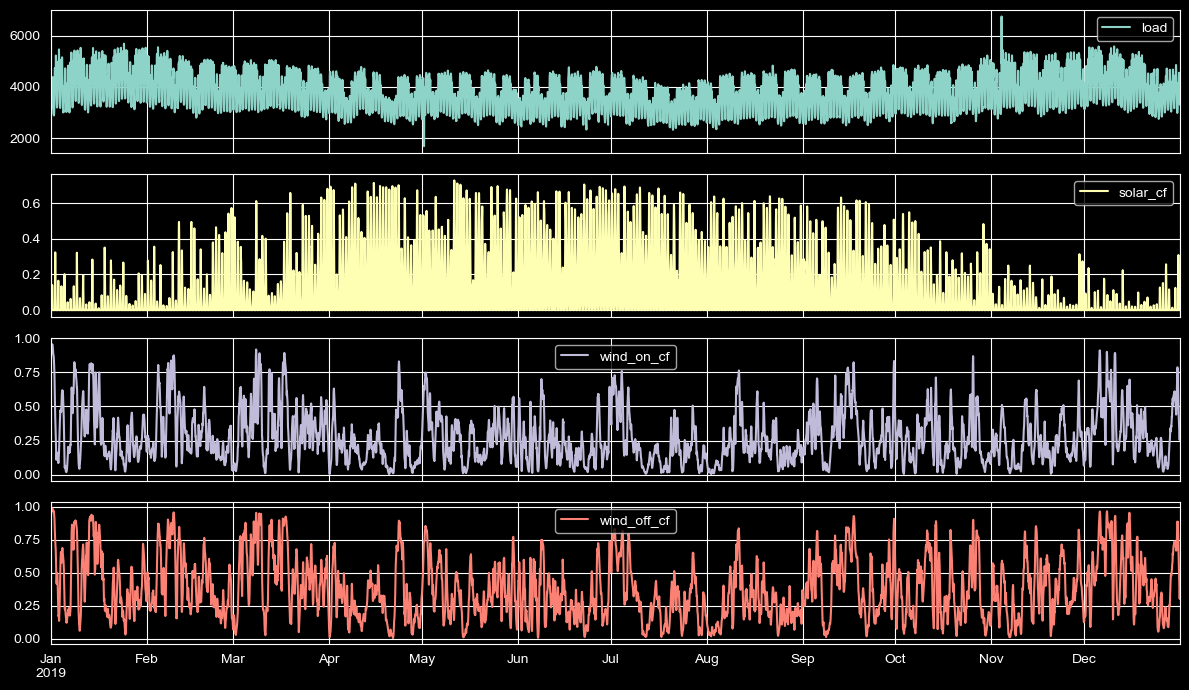

In [5]:
data[["load", "solar_cf", "wind_on_cf", "wind_off_cf"]].plot(subplots=True, figsize=(12,7)) #the true part is to have a graph per each variable, the figsize is to set the size of the figute to make the plots in scale.
plt.tight_layout() # adjusts the spacing between subplots to prevent overlap and ensure that the layout is visually appealing.
plt.show() # displays the plot on the screen.
#the plot part is just to check that the data is correct and how it looks like, we can see the load, solar and wind capacity factors for the whole year. Also would be good to use it in the report maybe or we can delete this lines.

3. Build the PyPSA network

In [6]:
n = pypsa.Network() # thiscreates a new PyPSA network object. This object represents the electricity system that we will analyze.
n.set_snapshots(snapshots) #we are setting the time resolution of the model.

n.add("Bus", "Denmark") #we are creating the bus, which in this model represents a node where electricity flows are balanced.

n.add(
    "Load",
    "demand",
    bus="Denmark",
    p_set=data["load"].values
)# we are adding the electricity demand to the bus. The p_set parameter specifies the time series of electricity demand that we want to meet at each snapshot.

n.add(
    "Generator",
    "solar",
    bus="Denmark",
    carrier="solar",
    p_max_pu=data["solar_cf"].values,
    p_nom_extendable=True,
    capital_cost=CAPITAL_COST_SOLAR,
    marginal_cost=MARGINAL_COST_SOLAR
)

n.add(
    "Generator",
    "wind_onshore",
    bus="Denmark",
    carrier="wind_onshore",
    p_max_pu=data["wind_on_cf"].values,
    p_nom_extendable=True,
    capital_cost= CAPITAL_COST_WIND_ON,
    marginal_cost=MARGINAL_COST_WIND_ON
)

n.add(
    "Generator",
    "wind_offshore",
    bus="Denmark",
    carrier="wind_offshore",
    p_max_pu=data["wind_off_cf"].values,
    p_nom_extendable=True,
    capital_cost=CAPITAL_COST_WIND_OFF,
    marginal_cost=MARGINAL_COST_WIND_OFF
)
n.add(
    "Generator",
    "gas",
    bus="Denmark",
    carrier="gas",
    p_nom_extendable=True,
    capital_cost=CAPITAL_COST_GAS,
    marginal_cost=MARGINAL_COST_GAS
)
# After defining the demand, we add three generation technologies to the system: solar, wind, and gas. All generators are connected to the Ireland bus. For solar and wind, the parameter p_max_pu uses the hourly capacity factors from the dataset, which represent how much of the installed capacity can generate electricity at each hour depending on weather conditions.
#The parameter p_nom_extendable=True allows the model to decide how much capacity to install for each technology during the optimization. Instead of fixing the generation capacity beforehand, the model determines the cost-optimal capacities based on the demand and the cost assumptions.

n.generators #prints the table of generators in the network 

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
solar,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
wind_onshore,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
wind_offshore,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
gas,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0


4. Optimise the system

In [7]:
n.sanitize()

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 5 missing carriers: ['AC', 'gas', 'solar', 'wind_offshore', 'wind_onshore']
INFO:pypsa.components._types.carriers:Assigned colors to 5 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.


In [8]:
n.optimize(solver_name="gurobi") # here we run the optimization of the electricity system model in PyPSA. During this step, the model calculates the cost-optimal solution for the system while ensuring that electricity demand is met at every hour of the year.

C:\Users\potoc\AppData\Local\Temp\ipykernel_10180\2402434390.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 302.66it/s]
INFO:linopy.io: Writing time: 0.16s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773856


INFO:gurobipy:Set parameter LicenseID to value 2773856


...

Solved in 4539 iterations and 1.29 seconds (0.56 work units)


INFO:gurobipy:Solved in 4539 iterations and 1.29 seconds (0.56 work units)


Optimal objective  2.167690929e+09


INFO:gurobipy:Optimal objective  2.167690929e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 2.17e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

5. Optimal installed capacities

In [9]:
n.generators[["carrier", "p_nom_opt"]] # this shows a table with the cost-optimal capacity mix for the Danish electricity system under the assumptions used in the model.

,carrier,p_nom_opt
name,,
solar,solar,9391.804006
wind_onshore,wind_onshore,11637.821199
wind_offshore,wind_offshore,0.000000
gas,gas,4826.148315


6. Annual generation and electricity mix

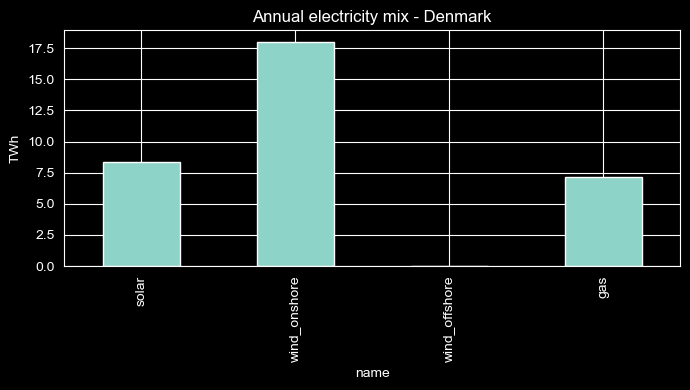

In [10]:
annual_gen = n.generators_t.p.sum() / 1e6   # convert the total electricity generated by each generator over the entire year MWh to TWh

fig, ax = plt.subplots(figsize=(7, 4)) #llustrates the contribution of each technology to total annual electricity generation.
annual_gen.plot.bar(ax=ax)
ax.set_title("Annual electricity mix - Denmark")
ax.set_ylabel("TWh")
plt.tight_layout()
plt.show()

6. Weekly dispatch in winter and summer

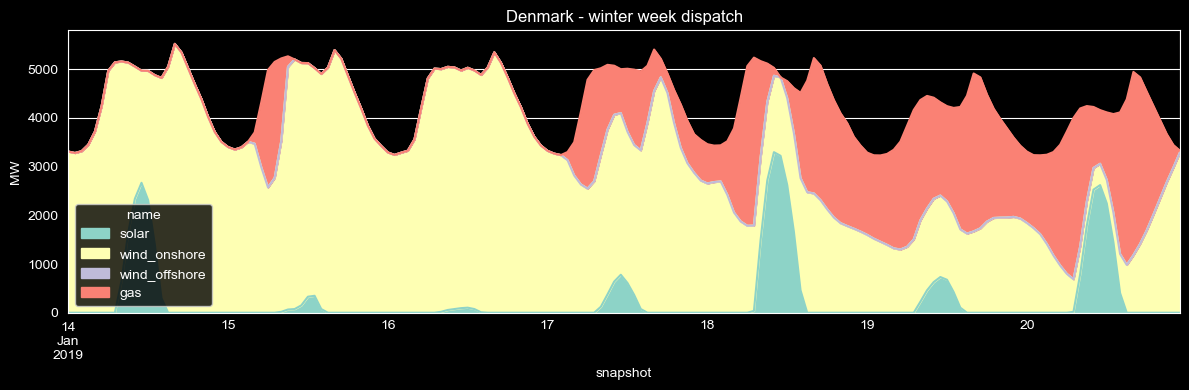

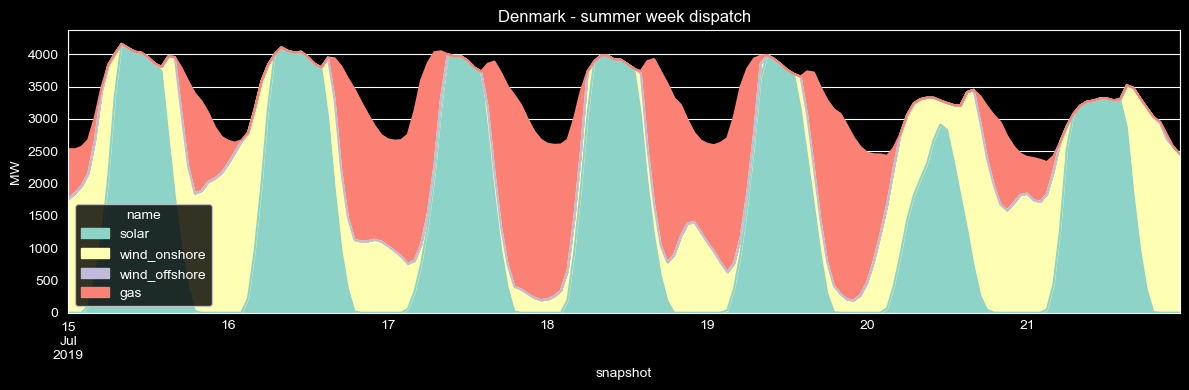

In [11]:
dispatch = n.generators_t.p.copy() #store the hourly power output of each generator in a new variable
dispatch.head()

fig, ax = plt.subplots(figsize=(12, 4))
dispatch.loc["2019-01-14":"2019-01-20"].plot.area(ax=ax)
ax.set_title("Denmark - winter week dispatch")
ax.set_ylabel("MW")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
dispatch.loc["2019-07-15":"2019-07-21"].plot.area(ax=ax)
ax.set_title("Denmark - summer week dispatch")
ax.set_ylabel("MW")
plt.tight_layout()
plt.show()

7. Capacity factors

In [12]:
capacity_factors = n.generators_t.p.sum() / (n.generators.p_nom_opt * len(n.snapshots)) #n.generators_t.p.sum() computes the total electricity produced by each generator over the entire year. The term n.generators.p_nom_opt represents the optimal installed capacity of each generator that was determined during the optimization, and len(n.snapshots) corresponds to the total number of hours simulated in the model(I THINK IT SHOULD BE 8760 HOURS)
capacity_factors
#dividing the total annual generation by the product of installed capacity and the number of hours, the code calculates the capacity factor. Thismeasures how intensively a power plant is used relative to its maximum possible output. 
#A value close to 1 would mean the generator is producing near its maximum capacity most of the time, while a lower value indicates that the generator operates less frequently or is limited by resource availability, as is the case for renewable technologies such as solar and wind.

name
solar            0.101375
wind_onshore     0.176818
wind_offshore         NaN
gas              0.169681
dtype: float64

8. Summary table

In [13]:
summary = pd.DataFrame({
    "installed_capacity_MW": n.generators.p_nom_opt,
    "annual_generation_MWh": n.generators_t.p.sum()
})

summary["capacity_factor"] = summary["annual_generation_MWh"] / (
    summary["installed_capacity_MW"] * len(n.snapshots)
)

summary["share_of_generation"] = summary["annual_generation_MWh"] / summary["annual_generation_MWh"].sum()

summary

,installed_capacity_MW,annual_generation_MWh,capacity_factor,share_of_generation
name,,,,
solar,9391.804006,8.340374e+06,0.101375,0.248669
wind_onshore,11637.821199,1.802610e+07,0.176818,0.537449
wind_offshore,0.000000,0.000000e+00,NaN,0.000000
gas,4826.148315,7.173606e+06,0.169681,0.213882


The optimization results show that the model installs offshore wind and gas capacity, while solar and onshore wind are not selected. This indicates that, under the assumed cost parameters and Danish renewable profiles, offshore wind is the most competitive renewable option, while gas provides dispatchable backup generation.